In [ ]:
#pip install lightgbm

In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 7

# LightGBM Regression

---

### Objectives

- Load Dataset
- Train LightGBM Model
- Evaluate Performance
- Analyze Feature Importance
- Save Model

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install lightgbm
# %pip install joblib

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [4]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print("Dataset Shape :", df.shape)

Dataset Shape : (8601, 33)


In [5]:
# ==============================================================================
# DEFINE TARGET
# ==============================================================================

TARGET = "Sales"

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [6]:
# ==============================================================================
# REMOVE UNNECESSARY COLUMNS
# ==============================================================================

if "Date" in X.columns:
    X.drop(columns=["Date"], inplace=True)

# Remove target leakage feature
if "Sales_Per_Customer" in X.columns:
    X.drop(columns=["Sales_Per_Customer"], inplace=True)

In [7]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = encoder.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [8]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (6880, 30)
Testing Shape : (1721, 30)


In [9]:
# ==============================================================================
# CREATE LIGHTGBM MODEL
# ==============================================================================

lgb_model = LGBMRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=31,

    random_state=42

)

print(lgb_model)

LGBMRegressor(learning_rate=0.05, max_depth=8, n_estimators=500,
              random_state=42)


In [10]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

lgb_model.fit(
    X_train,
    y_train
)

print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3533
[LightGBM] [Info] Number of data points in the train set: 6880, number of used features: 30
[LightGBM] [Info] Start training from score 75.673837
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [11]:
# ==============================================================================
# TRAIN PREDICTIONS
# ==============================================================================

y_train_pred = lgb_model.predict(X_train)

In [12]:
# ==============================================================================
# TEST PREDICTIONS
# ==============================================================================

y_test_pred = lgb_model.predict(X_test)

In [13]:
# ==============================================================================
# MODEL EVALUATION
# ==============================================================================

mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R² :", round(r2,4))

MAE : 8.33
MSE : 109.92
RMSE : 10.48
R² : 0.9614


In [14]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance = pd.DataFrame({

    "Metric":["MAE","MSE","RMSE","R²"],

    "Value":[mae,mse,rmse,r2]

})

performance

,Metric,Value
0,MAE,8.325945
1,MSE,109.923458
2,RMSE,10.484439
3,R²,0.961379


In [15]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_test_pred,

    "Error": y_test - y_test_pred

})

prediction_df.head(20)

,Actual,Predicted,Error
5839,6,11.129355,-5.129355
4275,91,92.593155,-1.593155
6086,49,41.849010,7.150990
8265,90,90.788979,-0.788979
5493,15,24.447532,-9.447532
1688,127,112.540779,14.459221
5241,59,53.102912,5.897088
221,53,65.867270,-12.867270
239,63,64.639835,-1.639835
2208,53,57.541601,-4.541601


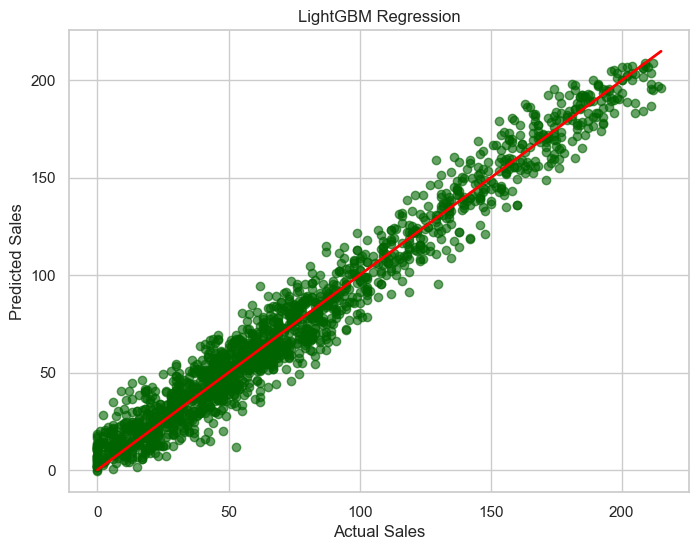

In [16]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    color="darkgreen"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("LightGBM Regression")

plt.show()

In [17]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": lgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
15,Customers,1460
14,Discount,924
26,Price_Difference,882
1,Product_ID,860
8,Fuel_Price,855
7,Temperature,829
9,CPI,803
10,Unemployment,770
11,Inventory,705
0,Store_ID,654


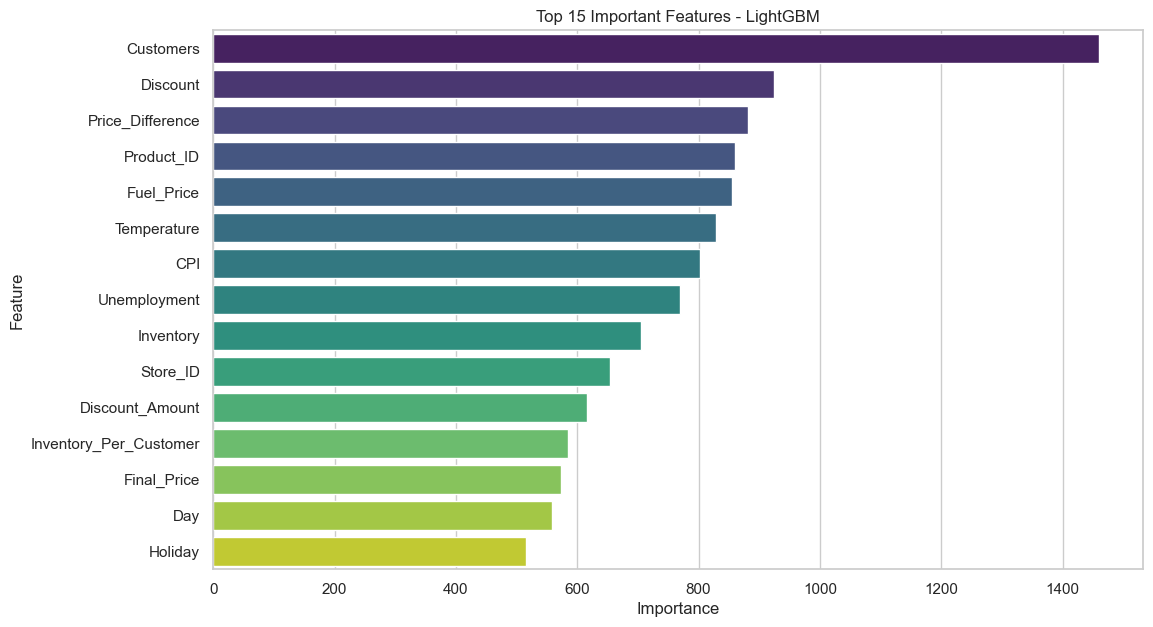

In [18]:
# ==============================================================================
# FEATURE IMPORTANCE PLOT
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features - LightGBM")

plt.show()

In [21]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", round(train_r2,4))

Training R² Score : 0.9898


In [22]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", round(test_r2,4))

Testing R² Score : 0.9614


In [23]:
# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-test_r2)*(n-1)/(n-p-1))

print("Adjusted R² :", round(adjusted_r2,4))

Adjusted R² : 0.9607


In [24]:
# ==============================================================================
# MAPE
# ==============================================================================

mape = np.mean(np.abs((y_test-y_test_pred)/y_test))*100

print("MAPE :", round(mape,2),"%")

MAPE : inf %


In [25]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

prediction_df["Residual"] = residuals

prediction_df.head()

,Actual,Predicted,Error,Residual
5839,6,11.129355,-5.129355,-5.129355
4275,91,92.593155,-1.593155,-1.593155
6086,49,41.849010,7.150990,7.150990
8265,90,90.788979,-0.788979,-0.788979
5493,15,24.447532,-9.447532,-9.447532


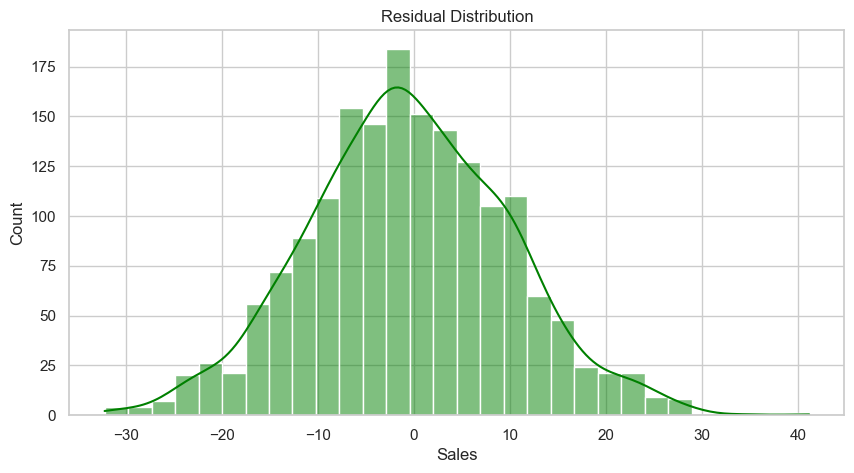

In [26]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="green"
)

plt.title("Residual Distribution")

plt.show()

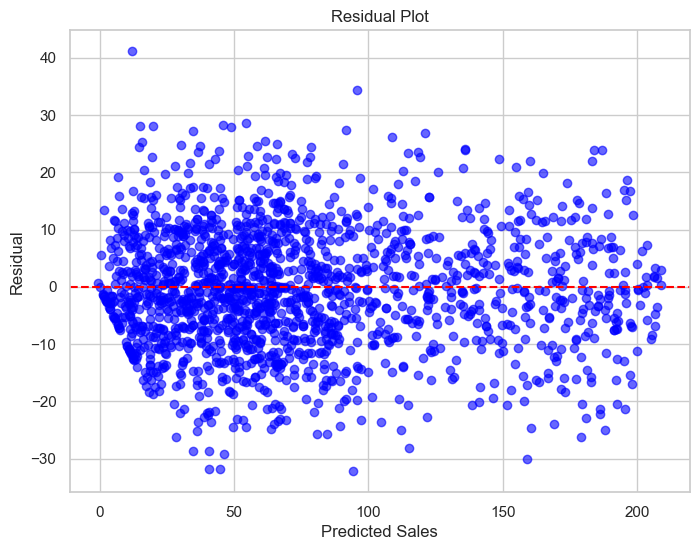

In [27]:
# ==============================================================================
# RESIDUAL SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6,
    color="blue"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

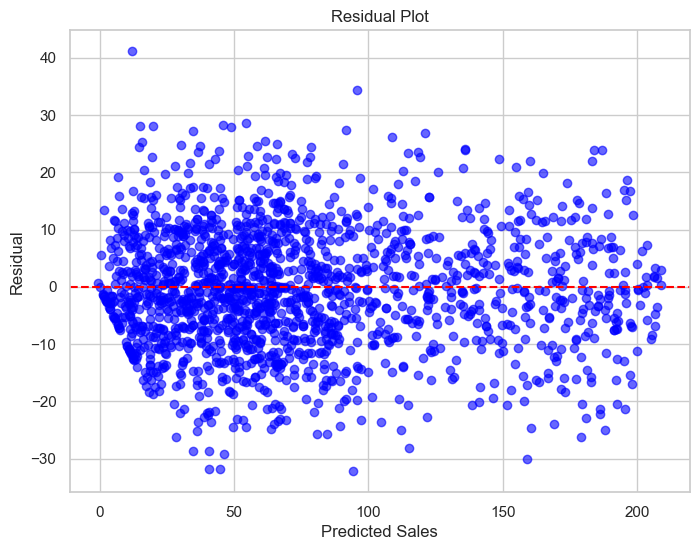

In [28]:
# ==============================================================================
# RESIDUAL SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6,
    color="blue"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [29]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lgb_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(cv_scores)

[0.9649338  0.96304833 0.96403056 0.96415282 0.96506382]


In [30]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", round(cv_scores.mean(),4))

Average CV Score : 0.9642


In [31]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE",
        "Cross Validation"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape,
        cv_scores.mean()
    ]

})

summary

,Metric,Value
0,MAE,8.325945
1,MSE,109.923458
2,RMSE,10.484439
3,R²,0.961379
4,Adjusted R²,0.960693
5,MAPE,inf
6,Cross Validation,0.964246


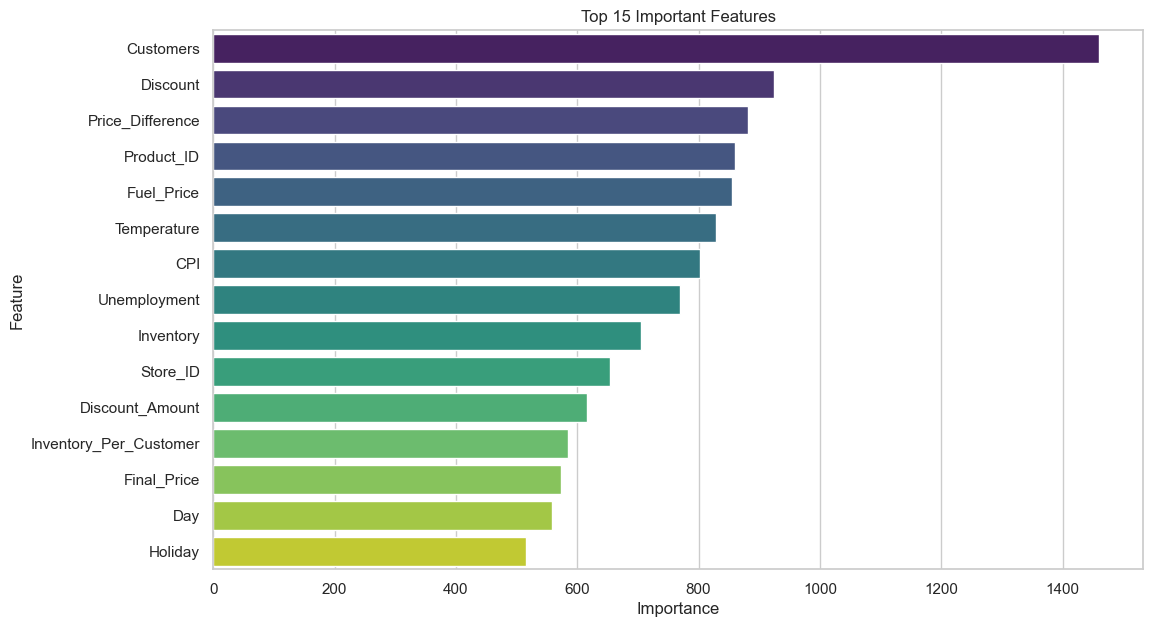

In [32]:
# ==============================================================================
# TOP 15 IMPORTANT FEATURES
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()

In [33]:
# ==============================================================================
# FEATURE IMPORTANCE TABLE
# ==============================================================================

importance.head(20)

,Feature,Importance
15,Customers,1460
14,Discount,924
26,Price_Difference,882
1,Product_ID,860
8,Fuel_Price,855
7,Temperature,829
9,CPI,803
10,Unemployment,770
11,Inventory,705
0,Store_ID,654


In [34]:
# ==============================================================================
# SAVE LIGHTGBM MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    lgb_model,
    "model/lightgbm_model.pkl"
)

print("LightGBM Model Saved Successfully")

LightGBM Model Saved Successfully


In [35]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/lightgbm_predictions.csv",
    index=False
)

print("Prediction File Saved Successfully")

Prediction File Saved Successfully


In [36]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/LightGBM_Performance.csv",
    index=False
)

print("Performance Report Saved Successfully")

Performance Report Saved Successfully


In [37]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

print(os.listdir("model"))

['decision_tree.pkl', 'label_encoder.pkl', 'lightgbm_model.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost_model.pkl']


In [38]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

print(os.listdir("dataset"))

['DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'LightGBM_Performance.csv', 'lightgbm_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv', 'RandomForest_Performance.csv', 'random_forest_predictions.csv', 'XGBoost_Performance.csv', 'xgboost_predictions.csv']


In [39]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- LightGBM is optimized for speed and efficiency.")
print("- It handles large retail datasets very effectively.")
print("- Feature importance helps identify demand drivers.")
print("- Cross-validation confirms model robustness.")
print("- Suitable for real-time retail demand prediction.")

Business Interpretation
- LightGBM is optimized for speed and efficiency.
- It handles large retail datasets very effectively.
- Feature importance helps identify demand drivers.
- Cross-validation confirms model robustness.
- Suitable for real-time retail demand prediction.


In [40]:
# ==============================================================================
# MODEL SUMMARY
# ==============================================================================

print("="*60)

print("LIGHTGBM MODEL SUMMARY")

print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Features Used    :", X.shape[1])

print("="*60)

LIGHTGBM MODEL SUMMARY
Training Samples : 6880
Testing Samples  : 1721
Features Used    : 30
